In [4]:
import torch as tc
import matplotlib.pyplot as plt


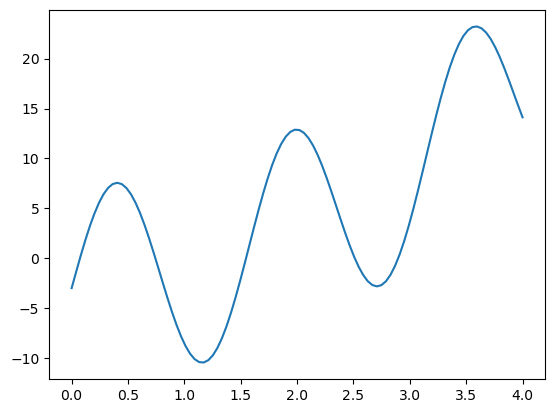

In [ ]:
def func(x):
    return x**2+x-3+tc.sin(x*4)*10

base_x = tc.linspace(0,4,100)

y = func(base_x)

plt.plot(base_x, y)


In [ ]:
NP = 30
D = 1
F = 0.5

lower_bound = 0

upper_bound = 4

max_it = 100

# população inicial
current_pop = (
    lower_bound
    + (upper_bound - lower_bound) * tc.rand(NP, D)
)

new_pop = tc.zeros_like(current_pop)


for _ in range(max_it):

    # para cada indivíduo da população
    for i in range(NP):

        # --------------------------------
        # 1. Escolher r1, r2, r3
        # --------------------------------

        # índices diferentes de i
        available = tc.arange(NP)
        available = available[available != i]

        indices = available[tc.randperm(NP - 1)[:3]]

        i1, i2, i3 = indices

        r1 = current_pop[i1]
        r2 = current_pop[i2]
        r3 = current_pop[i3]

        # --------------------------------
        # 2. Mutação DE/rand/1
        # --------------------------------

        mutant = r1 + F * (r2 - r3)

        # manter dentro dos limites
        mutant = tc.clamp(
            mutant,
            lower_bound,
            upper_bound
        )

        # --------------------------------
        # 3. Seleção
        # --------------------------------

        if func(mutant) < func(current_pop[i]):
            new_pop[i] = mutant
        else:
            new_pop[i] = current_pop[i]

    # --------------------------------
    # 4. Nova geração
    # --------------------------------

    current_pop = new_pop.clone()


# melhor solução encontrada
fitness = func(current_pop)

best_index = tc.argmin(fitness)

best_x = current_pop[best_index]
best_f = fitness[best_index]

print("Melhor x:", best_x.item())
print("Melhor f(x):", best_f.item())

Melhor x: 1.1573638916015625
Melhor f(x): -10.468775749206543
